<h2 style="color:green;text-align:center;font-weight:bold">Team ID : PTID-AIE-AUG-26-11126 - AIE <br> Project ID : PRCP-1009</h2>

---

**🌍 Business Objectives**

- Target variable : **`price_range`**

- ML Problem Type:
  - It is a classification problem. The target Variable has multi-class labels. They are **Low cost Phones** ,**Medium cost Phones** , **High cost Phones** , **Very High cost Phones**

- Model Evaluation:
  - Model can be Evaluated using **Accuracy_score**, **pricision_score** , **F1-score** , **Recall-score**


**Importing all required libraries**

In [1]:
# importing core libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


# pandas configurations
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',100)
pd.set_option('display.width',1000)


# Matplotlib custom settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')


# statistics
from scipy import stats

print(f'✅ Importing all the Required core libraries.')

✅ Importing all the Required core libraries.


<h3 style='color:orange;font-weight:bold'>🎯 Task 1 : Prepare a complete data analysis report on the given data</h3>

---

In [2]:

print(f'='*50)
print(f'📱 Complete Data Analysis Report on Cell Phone Price Prediction')
print(f'='*50)

# read the csv file
dataset_path = "Data/datasets_11167_15520_train.csv"
df = pd.read_csv(dataset_path)

# shape
row,cols = df.shape
size = df.size
print(f'\n🐍 Shape of the Dataset : \n')
print(f'Dataset Contains : {row} Rows * {cols} Cols.')
print(f'Dataset Contains : {size:,} Records (Size)\n')

# data types
print('='*20)
data_types = df.dtypes.value_counts()
print(f'\n🔍 Data types in the Dataset : \n')
print(f'{data_types}\n')


# Missing values
print(f'='*20)
missing_count = df.isnull().sum()
missing_pct = missing_count/len(df)
missing_df = pd.DataFrame({
  "missing_Count" : missing_count,
  "missing_pct" : missing_pct
}).reset_index()
missing_df.columns = ['Column_name','Missing_Count','Missing_Percentage']
print(f'\n🚨 Column wise Missing Values in the Dataset : \n')
print(f'{missing_df}\n')


# Exact Duplicates
print(f'='*20)
exact_duplicates = df.duplicated().sum()
print(f'\n🪡 Counting Exact Duplicate Rows : {exact_duplicates}\n')


# Numerical Column Analysis
print(f'='*20)
print(f'\n🔢 Numerical Columns Analysis :\n')
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f'Number of Numerical Columns : {len(numerical_cols)}')
print(f'Numerical Columns : \n{numerical_cols}\n')
skewness = []
kurtosis = []
skewness_impact = []
kurtosis_impact = []
for col in numerical_cols:
  skew = df[col].skew()
  kurto = stats.kurtosis(df[col],fisher=True,nan_policy='omit')
  skewness.append(skew)
  kurtosis.append(kurto)
  
  skew_effect = ""
  kurtosis_effect = ""
  
  # calculate skewness impact
  if -0.5 <= skew <= 0.5:
    skew_effect = "✅ Approximately symmetric."
  elif -1.0 <= skew <= -0.5:
    skew_effect = "⚠️ Moderately Left Skewed."
  elif 0.5 <= skew <= 1:
    skew_effect = "⚠️ Moderately Right Skewed."
  elif skew > 1:
    skew_effect = "❌ Highly Right Skewed."
  else:
    skew_effect = "❌ Highly Left Skewed."
  
  # calculate kurtosis effect:
  if -1 <= kurto <= 1:
    kurtosis_effect = "✅ Approximately Normal."
  elif kurto > 1:
    kurtosis_effect = "❌ Heavy Tails (More Outliers)."
  else:
    kurtosis_effect = "⚠️ Lighter Tails (Fewer Outliers)"
    
  skewness_impact.append(skew_effect)
  kurtosis_impact.append(kurtosis_effect)

numerical_cols_analysis = pd.DataFrame({
  "Columns" : numerical_cols,
  "skewness" : skewness,
  "skewness_Impact" : skewness_impact,
  "Kurtosis" : kurtosis,
  "Kurtosis_Impact" : kurtosis_impact
})

print(numerical_cols_analysis)


📱 Complete Data Analysis Report on Cell Phone Price Prediction

🐍 Shape of the Dataset : 

Dataset Contains : 2000 Rows * 21 Cols.
Dataset Contains : 42,000 Records (Size)


🔍 Data types in the Dataset : 

int64      19
float64     2
Name: count, dtype: int64


🚨 Column wise Missing Values in the Dataset : 

      Column_name  Missing_Count  Missing_Percentage
0   battery_power              0                 0.0
1            blue              0                 0.0
2     clock_speed              0                 0.0
3        dual_sim              0                 0.0
4              fc              0                 0.0
5          four_g              0                 0.0
6      int_memory              0                 0.0
7           m_dep              0                 0.0
8       mobile_wt              0                 0.0
9         n_cores              0                 0.0
10             pc              0                 0.0
11      px_height              0                 0.0
1

In [52]:
# Visualize the sample of a dataset features

df.sample(10)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
268,1283,1,1.6,1,4,0,47,0.9,93,5,5,372,692,2698,9,6,17,1,1,0,2
1030,1681,1,2.5,1,6,0,18,0.3,167,1,7,850,1005,2265,5,3,20,1,1,1,2
45,1514,0,2.9,0,0,0,27,0.2,118,3,1,186,1810,1152,8,3,20,0,1,1,1
727,1590,0,0.6,1,0,0,7,0.3,122,3,17,1464,1595,1201,12,3,18,1,1,1,1
336,580,1,1.2,1,0,0,47,0.9,91,3,1,1086,1345,3451,15,1,11,1,1,0,3
387,560,0,0.5,0,14,0,23,1.0,146,8,15,356,1903,2360,17,16,18,0,1,1,1
279,823,1,0.5,0,0,0,39,0.4,187,8,4,630,888,294,13,9,11,0,0,1,0
1283,840,0,1.2,1,5,1,15,0.3,178,6,8,526,1728,2636,12,2,6,1,1,0,2
1433,659,0,2.2,0,0,1,24,0.7,151,8,2,924,1877,3925,8,1,10,1,1,1,3
1546,1776,0,2.2,0,2,0,20,0.9,82,6,16,1563,1803,2671,15,10,12,0,1,1,3


In [3]:
print(f'🌍 General Information about the Dataset : \n')
df.info()

🌍 General Information about the Dataset : 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g 

In [4]:
print(f'🔢 Five Summary Statistics about the Dataset : \n')
df.describe().transpose()

🔢 Five Summary Statistics about the Dataset : 



,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


**🚨 Data Validation**

In [5]:
print(f'📊 Data Validation for Numerical Columns : \n')

for col in numerical_cols:
  print(f'{col:15s} → NUnique = [{df[col].nunique()}] | Dtype : {df[col].dtype} | Range : [{int(df[col].min())} → {int(df[col].max())}]')

📊 Data Validation for Numerical Columns : 

battery_power   → NUnique = [1094] | Dtype : int64 | Range : [501 → 1998]
blue            → NUnique = [2] | Dtype : int64 | Range : [0 → 1]
clock_speed     → NUnique = [26] | Dtype : float64 | Range : [0 → 3]
dual_sim        → NUnique = [2] | Dtype : int64 | Range : [0 → 1]
fc              → NUnique = [20] | Dtype : int64 | Range : [0 → 19]
four_g          → NUnique = [2] | Dtype : int64 | Range : [0 → 1]
int_memory      → NUnique = [63] | Dtype : int64 | Range : [2 → 64]
m_dep           → NUnique = [10] | Dtype : float64 | Range : [0 → 1]
mobile_wt       → NUnique = [121] | Dtype : int64 | Range : [80 → 200]
n_cores         → NUnique = [8] | Dtype : int64 | Range : [1 → 8]
pc              → NUnique = [21] | Dtype : int64 | Range : [0 → 20]
px_height       → NUnique = [1137] | Dtype : int64 | Range : [0 → 1960]
px_width        → NUnique = [1109] | Dtype : int64 | Range : [500 → 1998]
ram             → NUnique = [1562] | Dtype : int64 | Range 

**Note:**

---

`Change Dataypes form Numerical -> Categorical`
1. blue
2. dual_sim
3. four_g
4. n_cores
5. three_g
6. touch_screen
7. wifi
8. Price_range

In [6]:
# Change the Datatype of Numerical to Categorical Columns. 

change_dtype_cols = ['blue','dual_sim','four_g','n_cores','three_g','touch_screen','wifi','price_range']

for col in change_dtype_cols:
  df[col] = df[col].astype('str')

In [7]:
print(f'📊 Data Validation of Categorical Columns : \n')

categorical_columns = df.select_dtypes(include='object').columns.tolist()

for col in categorical_columns:
  print(f'{col:10s} → NUnique : {df[col].nunique()} | Unique Values : \n{df[col].unique()}\n')

📊 Data Validation of Categorical Columns : 

blue       → NUnique : 2 | Unique Values : 
['0' '1']

dual_sim   → NUnique : 2 | Unique Values : 
['0' '1']

four_g     → NUnique : 2 | Unique Values : 
['0' '1']

n_cores    → NUnique : 8 | Unique Values : 
['2' '3' '5' '6' '1' '8' '4' '7']

three_g    → NUnique : 2 | Unique Values : 
['0' '1']

touch_screen → NUnique : 2 | Unique Values : 
['0' '1']

wifi       → NUnique : 2 | Unique Values : 
['1' '0']

price_range → NUnique : 4 | Unique Values : 
['1' '2' '3' '0']



<h4 style='color:orange;text-align:center;font-weight:bold'>📘 Complete Detailed Analysis Report</h4>

---

**Data Types**
- Numerical Columns : 13
- Categorical Columns : 8


**Missing Values**
- Dataset Does not contain Missing values


**Numerical columns Distributions**
- Front Camera Mega Pixels (FC) : Having Highly Right skewed with Skewness **1.019811**
- Remaining all Numerical Columns Follows Approximately Normal Distribution


**Data Validation**
- Change the columns Data Types from Numerical to Categorical Data type. Beacause It has Discrete Unique Values.

`Changed Columns are :`
1. Bluetooth (blue)
2. Dual Sim
3. Four_G
4. n_cores
5. three_g
6. tourch_screen
7. wifi
8. Price_range

---

**🎯 Target Variable Analysis**

🌍 Target Variable : price_range

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64


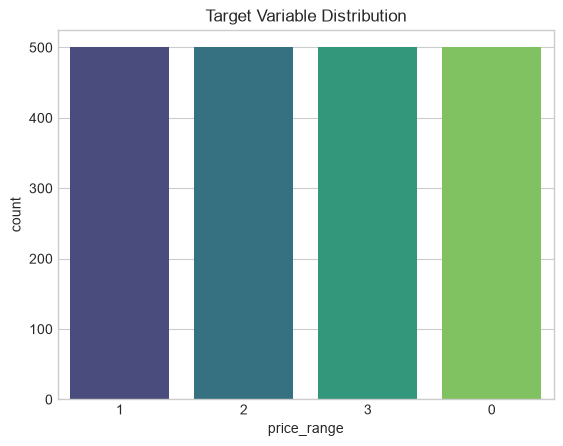

In [8]:
# Target variale : Price_range
print(f'🌍 Target Variable : price_range\n')
print(df['price_range'].value_counts())

sns.countplot(x=df['price_range'],palette='viridis')
plt.title('Target Variable Distribution')
plt.show()

**⭕ Exploratory Data Analysis**

**Numerical Columns Analysis**

🚨 Univariate Numerical columns Analysis : 

          Columns  skewness  Kurtosis
0   battery_power  0.031898 -1.224084
2     clock_speed  0.178084 -1.323109
4              fc  1.019811  0.273386
6      int_memory  0.057889 -1.216034
7           m_dep  0.089082 -1.274164
8       mobile_wt  0.006558 -1.210351
10             pc  0.017306 -1.171571
11      px_height  0.666271 -0.318075
12       px_width  0.014787 -1.186041
13            ram  0.006628 -1.191934
14           sc_h -0.098884 -1.190815
15           sc_w  0.633787 -0.391548
16      talk_time  0.009512 -1.218545


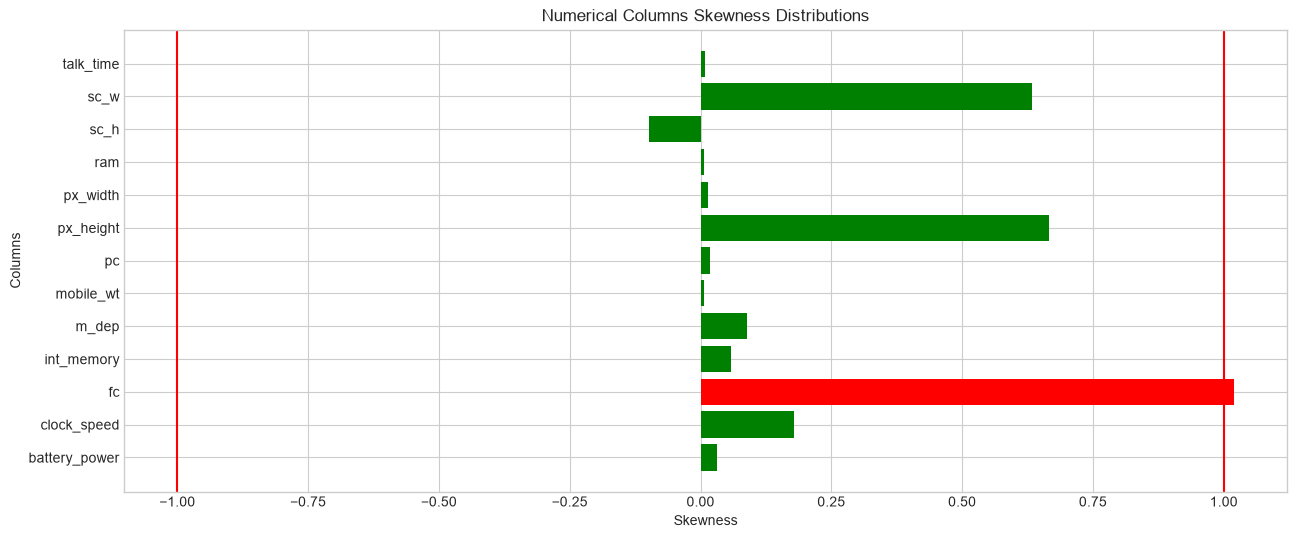

In [9]:
print(f'🚨 Univariate Numerical columns Analysis : \n')

numerical_cols_analysis = numerical_cols_analysis[~numerical_cols_analysis['Columns'].isin(categorical_columns)]

print(f'{numerical_cols_analysis[['Columns','skewness','Kurtosis']]}')

colors = ['red' if skew < -1 or skew > 1 else 'green' for skew in numerical_cols_analysis['skewness']]


plt.figure(figsize=(15,6))
plt.barh(numerical_cols_analysis['Columns'],numerical_cols_analysis['skewness'],align='center',color=colors)
plt.xlabel('Skewness')
plt.ylabel('Columns')
plt.title('Numerical Columns Skewness Distributions')
plt.axvline(-1,color='red')
plt.axvline(1,color='red')
plt.legend()
plt.show()


<Axes: xlabel='fc', ylabel='Count'>

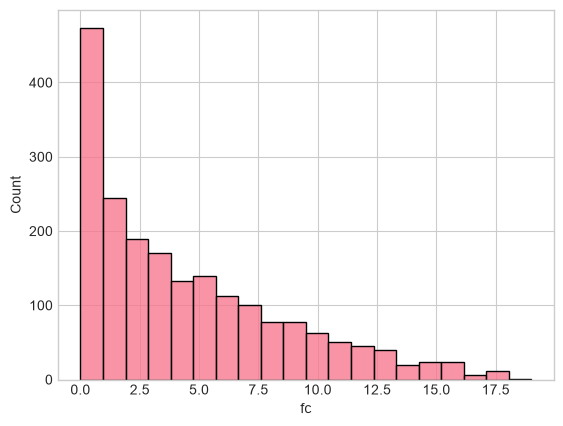

In [10]:
# Distribution of fc

sns.histplot(df['fc'])

In [11]:
# Correlation between Target Variable and Numerical variables

num_cols = df.select_dtypes(include=np.number).columns.tolist()

print(f'🔢 Correlation between Numerical Variables and Target Variable : \n')

"""
Choosing the Annova Test. Beacuse Target variable has more than 2 unique categories
and Numerical columns are normal distribution.
"""

corr_num_tar_result = []

# calcualate ANNOVA effect size
def calculate_eta_squared(groups):
  # combine all observations
  all_values = np.concatenate(groups)
  # all means
  grand_mean = np.mean(all_values)
  
  # ss Between
  ss_between = sum(
    len(group) * (np.mean(group) - grand_mean) ** 2
    for group in groups
  )
  # ss total
  ss_total = sum(
    (x-grand_mean) ** 2
    for x in all_values
  )
  eta_squared = ss_between / ss_total
  
  return eta_squared

for col in num_cols:
  
  groups = [groups[col].dropna() for _,groups in df.groupby('price_range')]

  f_stat,p_value = stats.f_oneway(*groups)
  
  eta_squared = calculate_eta_squared(groups)
  
  if p_value < 0.05:
    print(f'{col:15s} → ✅ Correlation Exist | p-value : {p_value:.2f} | eta-squared : {eta_squared:.2f}')
  else:
    print(f'{col:15s} → ❌ Correlation No Exit | p-value : {p_value:.2f} | eta-squared : {eta_squared:.2f}')
  
  corr_num_tar_result.append({
    "column" : col,
    "p-val" : round(p_value,3),
    'eta-squared' : eta_squared
  })
  
  
  

🔢 Correlation between Numerical Variables and Target Variable : 

battery_power   → ✅ Correlation Exist | p-value : 0.00 | eta-squared : 0.05
clock_speed     → ❌ Correlation No Exit | p-value : 0.69 | eta-squared : 0.00
fc              → ❌ Correlation No Exit | p-value : 0.51 | eta-squared : 0.00
int_memory      → ✅ Correlation Exist | p-value : 0.03 | eta-squared : 0.00
m_dep           → ❌ Correlation No Exit | p-value : 0.21 | eta-squared : 0.00
mobile_wt       → ✅ Correlation Exist | p-value : 0.01 | eta-squared : 0.01
pc              → ❌ Correlation No Exit | p-value : 0.48 | eta-squared : 0.00
px_height       → ✅ Correlation Exist | p-value : 0.00 | eta-squared : 0.03
px_width        → ✅ Correlation Exist | p-value : 0.00 | eta-squared : 0.03
ram             → ✅ Correlation Exist | p-value : 0.00 | eta-squared : 0.84
sc_h            → ❌ Correlation No Exit | p-value : 0.08 | eta-squared : 0.00
sc_w            → ❌ Correlation No Exit | p-value : 0.17 | eta-squared : 0.00
talk_time 

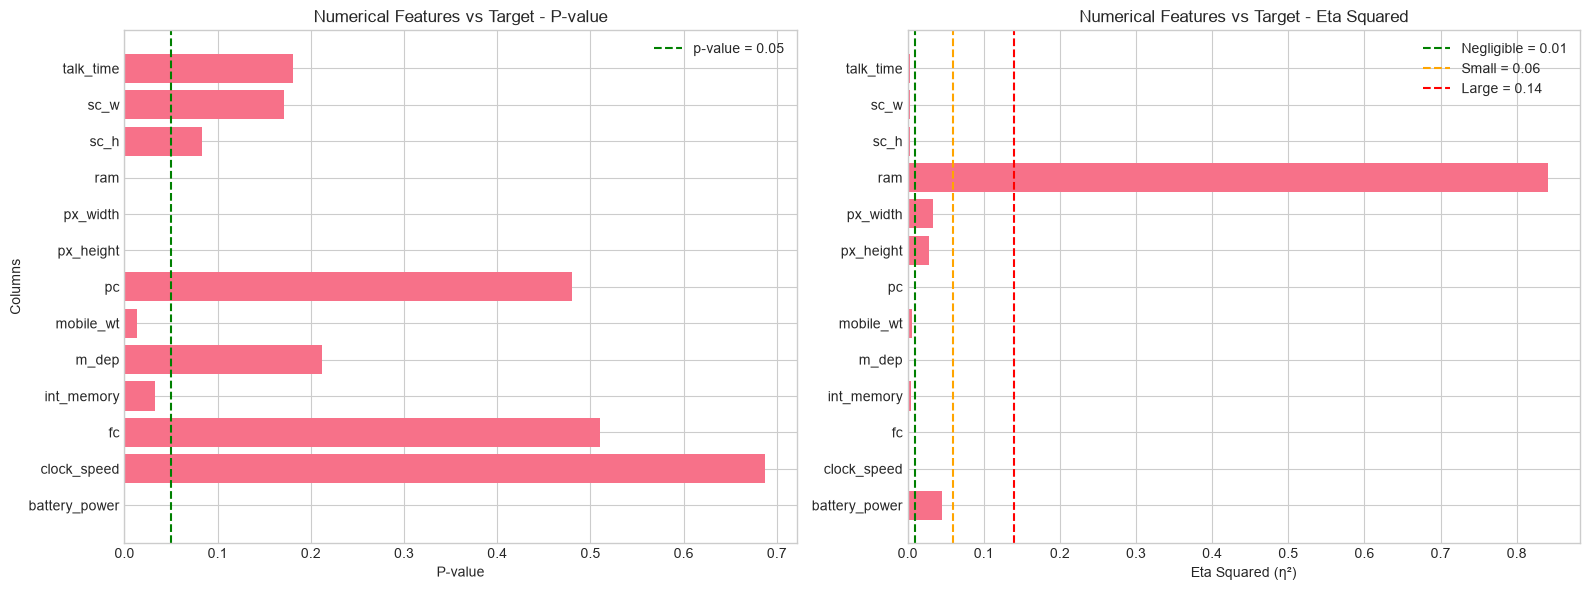

In [12]:
# visualization of p-value and eta squared exist

corr_num_tar_result_df = pd.DataFrame(corr_num_tar_result)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. P-value

ax[0].barh(
    corr_num_tar_result_df['column'],
    corr_num_tar_result_df['p-val']
)

ax[0].axvline(
    0.05,
    color='green',
    linestyle='--',
    label='p-value = 0.05'
)

ax[0].set_xlabel('P-value')
ax[0].set_ylabel('Columns')
ax[0].set_title('Numerical Features vs Target - P-value')
ax[0].legend()

# 2. Eta Squared

ax[1].barh(
    corr_num_tar_result_df['column'],
    corr_num_tar_result_df['eta-squared']
)

ax[1].axvline(
    0.01,
    color='green',
    linestyle='--',
    label='Negligible = 0.01'
)

ax[1].axvline(
    0.06,
    color='orange',
    linestyle='--',
    label='Small = 0.06'
)

ax[1].axvline(
    0.14,
    color='red',
    linestyle='--',
    label='Large = 0.14'
)

ax[1].set_xlabel('Eta Squared (η²)')
ax[1].set_title('Numerical Features vs Target - Eta Squared')
ax[1].legend()


plt.tight_layout()
plt.show()



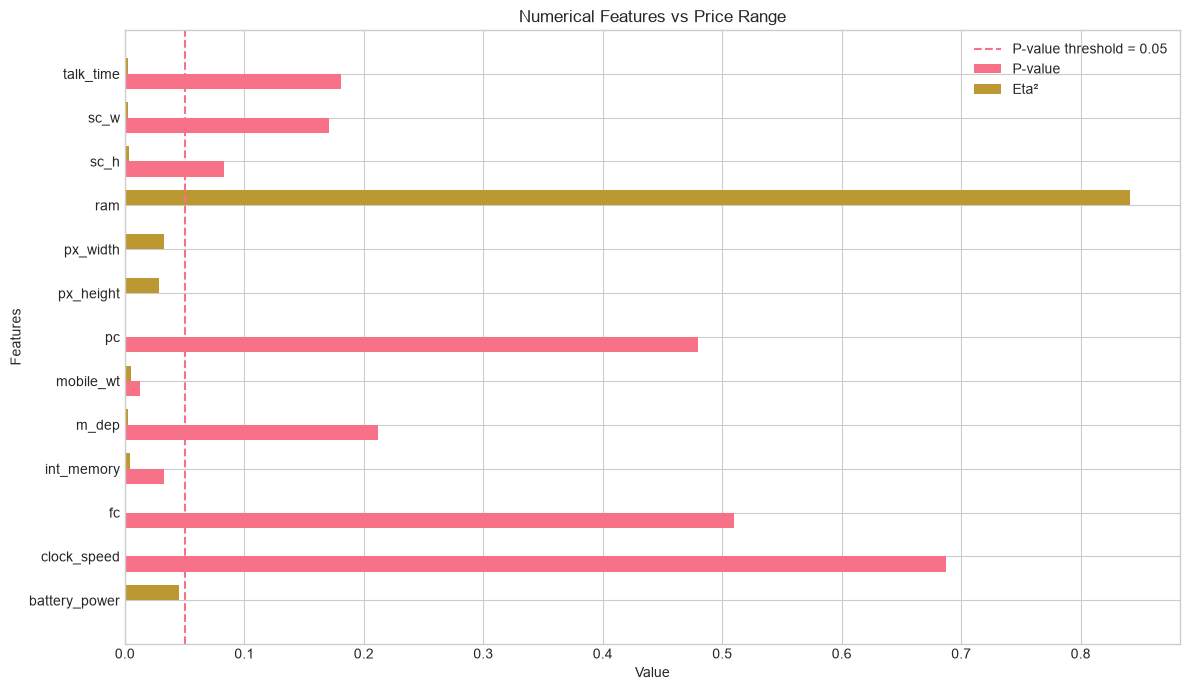

In [13]:

corr_num_tar_result_df = pd.DataFrame(corr_num_tar_result)

y = np.arange(len(corr_num_tar_result_df))
height = 0.35

plt.figure(figsize=(12, 7))

plt.barh(
    y - height/2,
    corr_num_tar_result_df['p-val'],
    height=height,
    label='P-value'
)

plt.barh(
    y + height/2,
    corr_num_tar_result_df['eta-squared'],
    height=height,
    label='Eta²'
)

plt.axvline(
    0.05,
    linestyle='--',
    label='P-value threshold = 0.05'
)

plt.yticks(
    y,
    corr_num_tar_result_df['column']
)

plt.xlabel('Value')
plt.ylabel('Features')
plt.title('Numerical Features vs Price Range')
plt.legend()

plt.tight_layout()
plt.show()

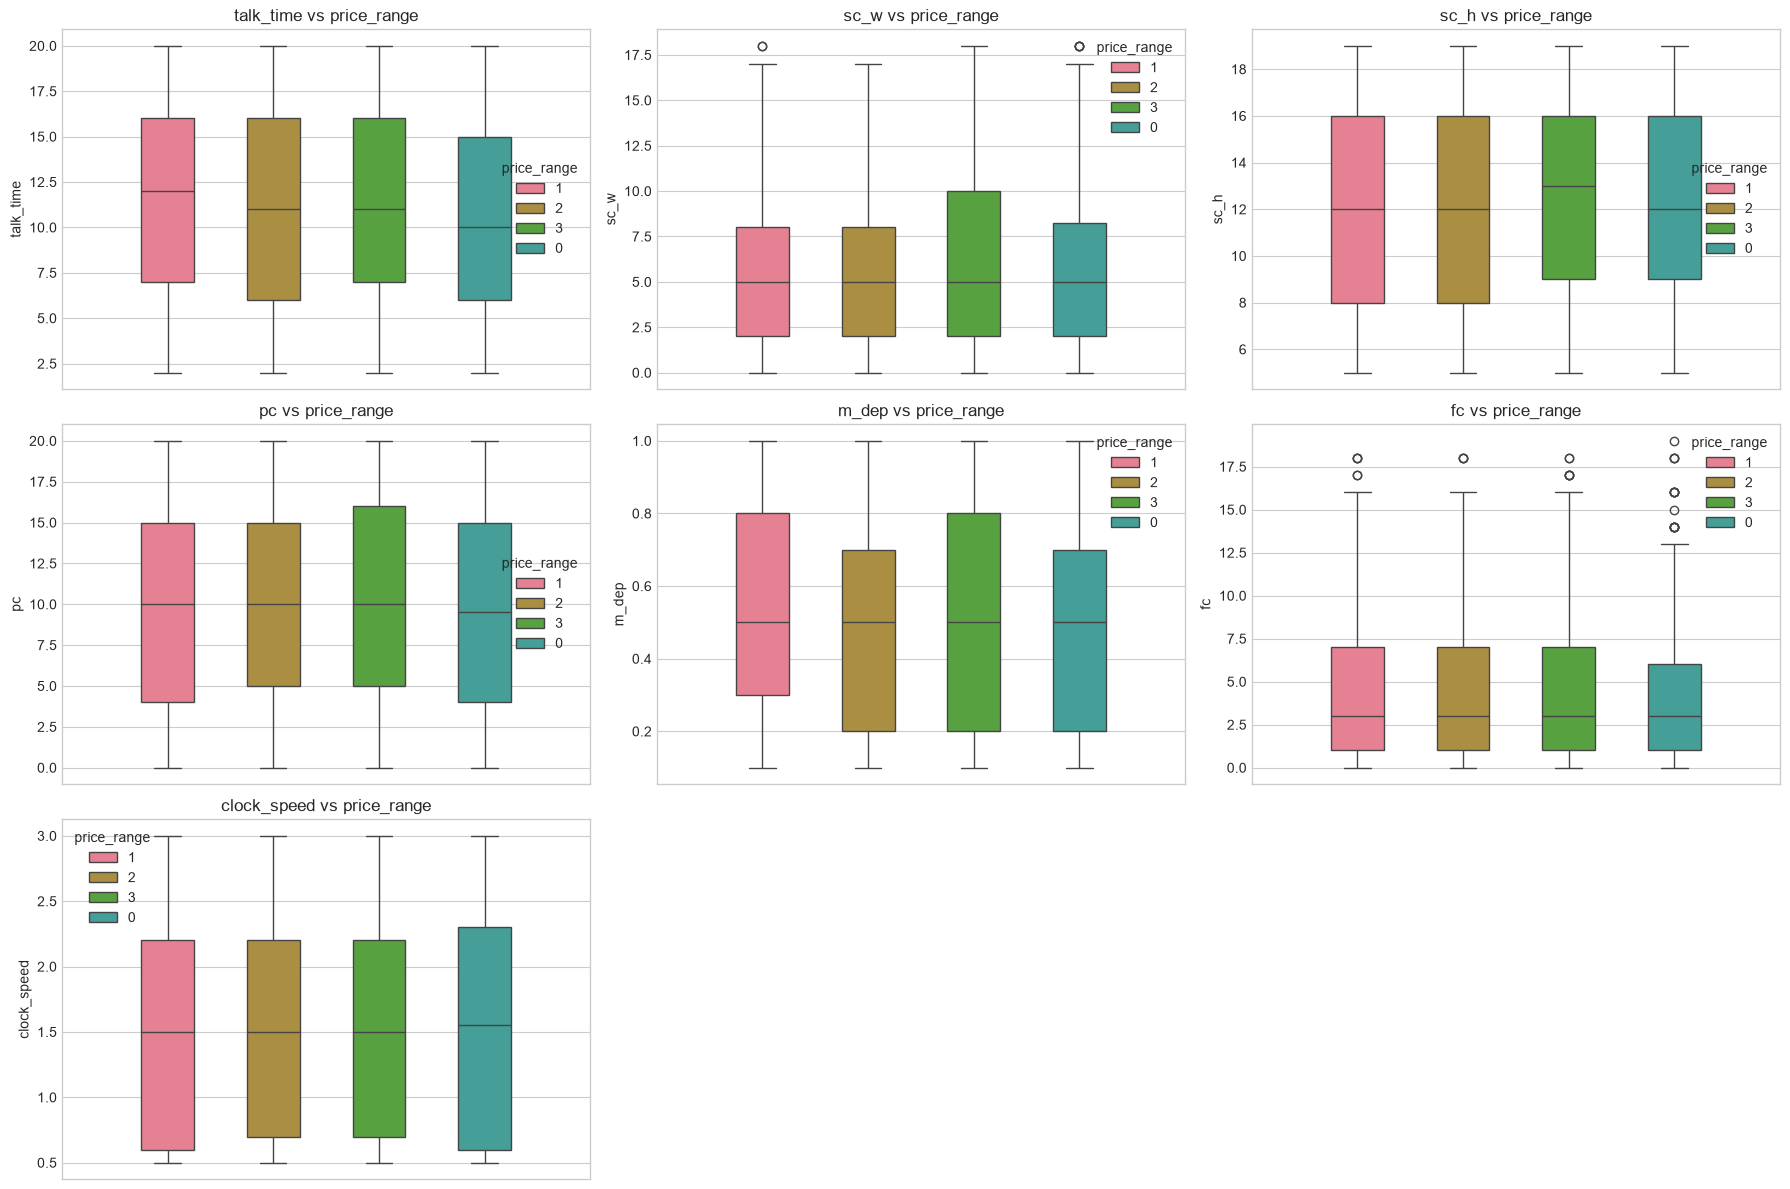

In [14]:
# Understanding why some columns are not coorelated with target variables

p_val_gt_cols = ['talk_time','sc_w','sc_h','pc','m_dep','fc','clock_speed']

fig,ax = plt.subplots(3,3,figsize=(18,12))
ax = ax.flatten()

for i,col in enumerate(p_val_gt_cols):
  sns.boxplot(y=df[col],hue=df['price_range'],ax=ax[i],gap=0.5)
  ax[i].set_title(f'{col} vs price_range')

# remove unused axes
for axis in ax[len(p_val_gt_cols):]:
  plt.delaxes(axis)
  
plt.tight_layout()
plt.show()

👁️ Multicollinearity among Numerical columns : 



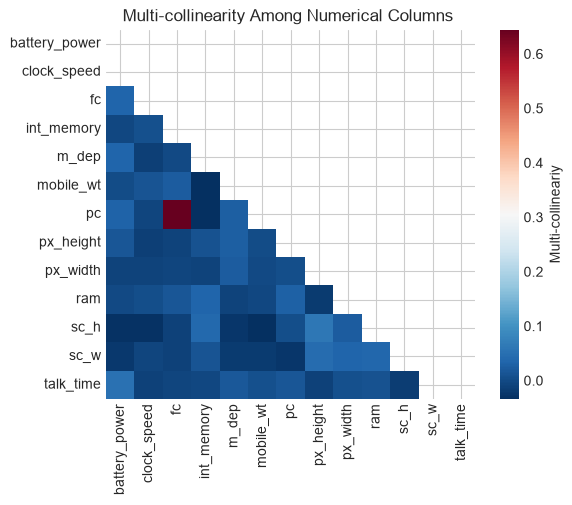

In [15]:
# Finding Multicollinearity among numerical columns

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

print(f'👁️ Multicollinearity among Numerical columns : \n')

corr = df[numerical_cols].corr()

mask = np.triu(np.ones_like(corr,dtype=bool),k=-1)

sns.heatmap(
  corr,
  mask=mask,
  fmt='.2f',
  square=True,
  cmap='RdBu_r',
  cbar_kws={'label':'Multi-collineariy'}
)

plt.title('Multi-collinearity Among Numerical Columns ')
plt.show()

<Axes: xlabel='pc', ylabel='fc'>

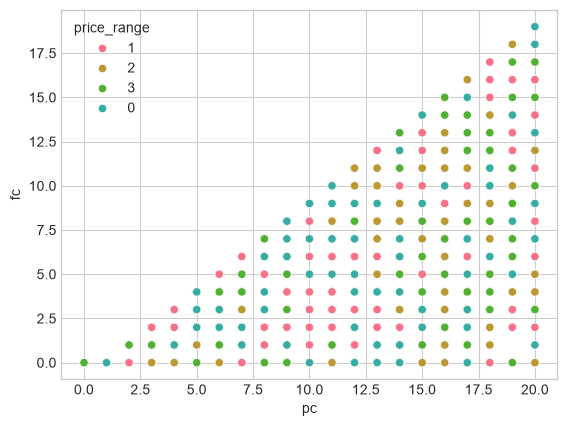

In [16]:
# Visualization of Relationship between FC and PC

sns.scatterplot(x=df['pc'],y=df['fc'],hue=df['price_range'])

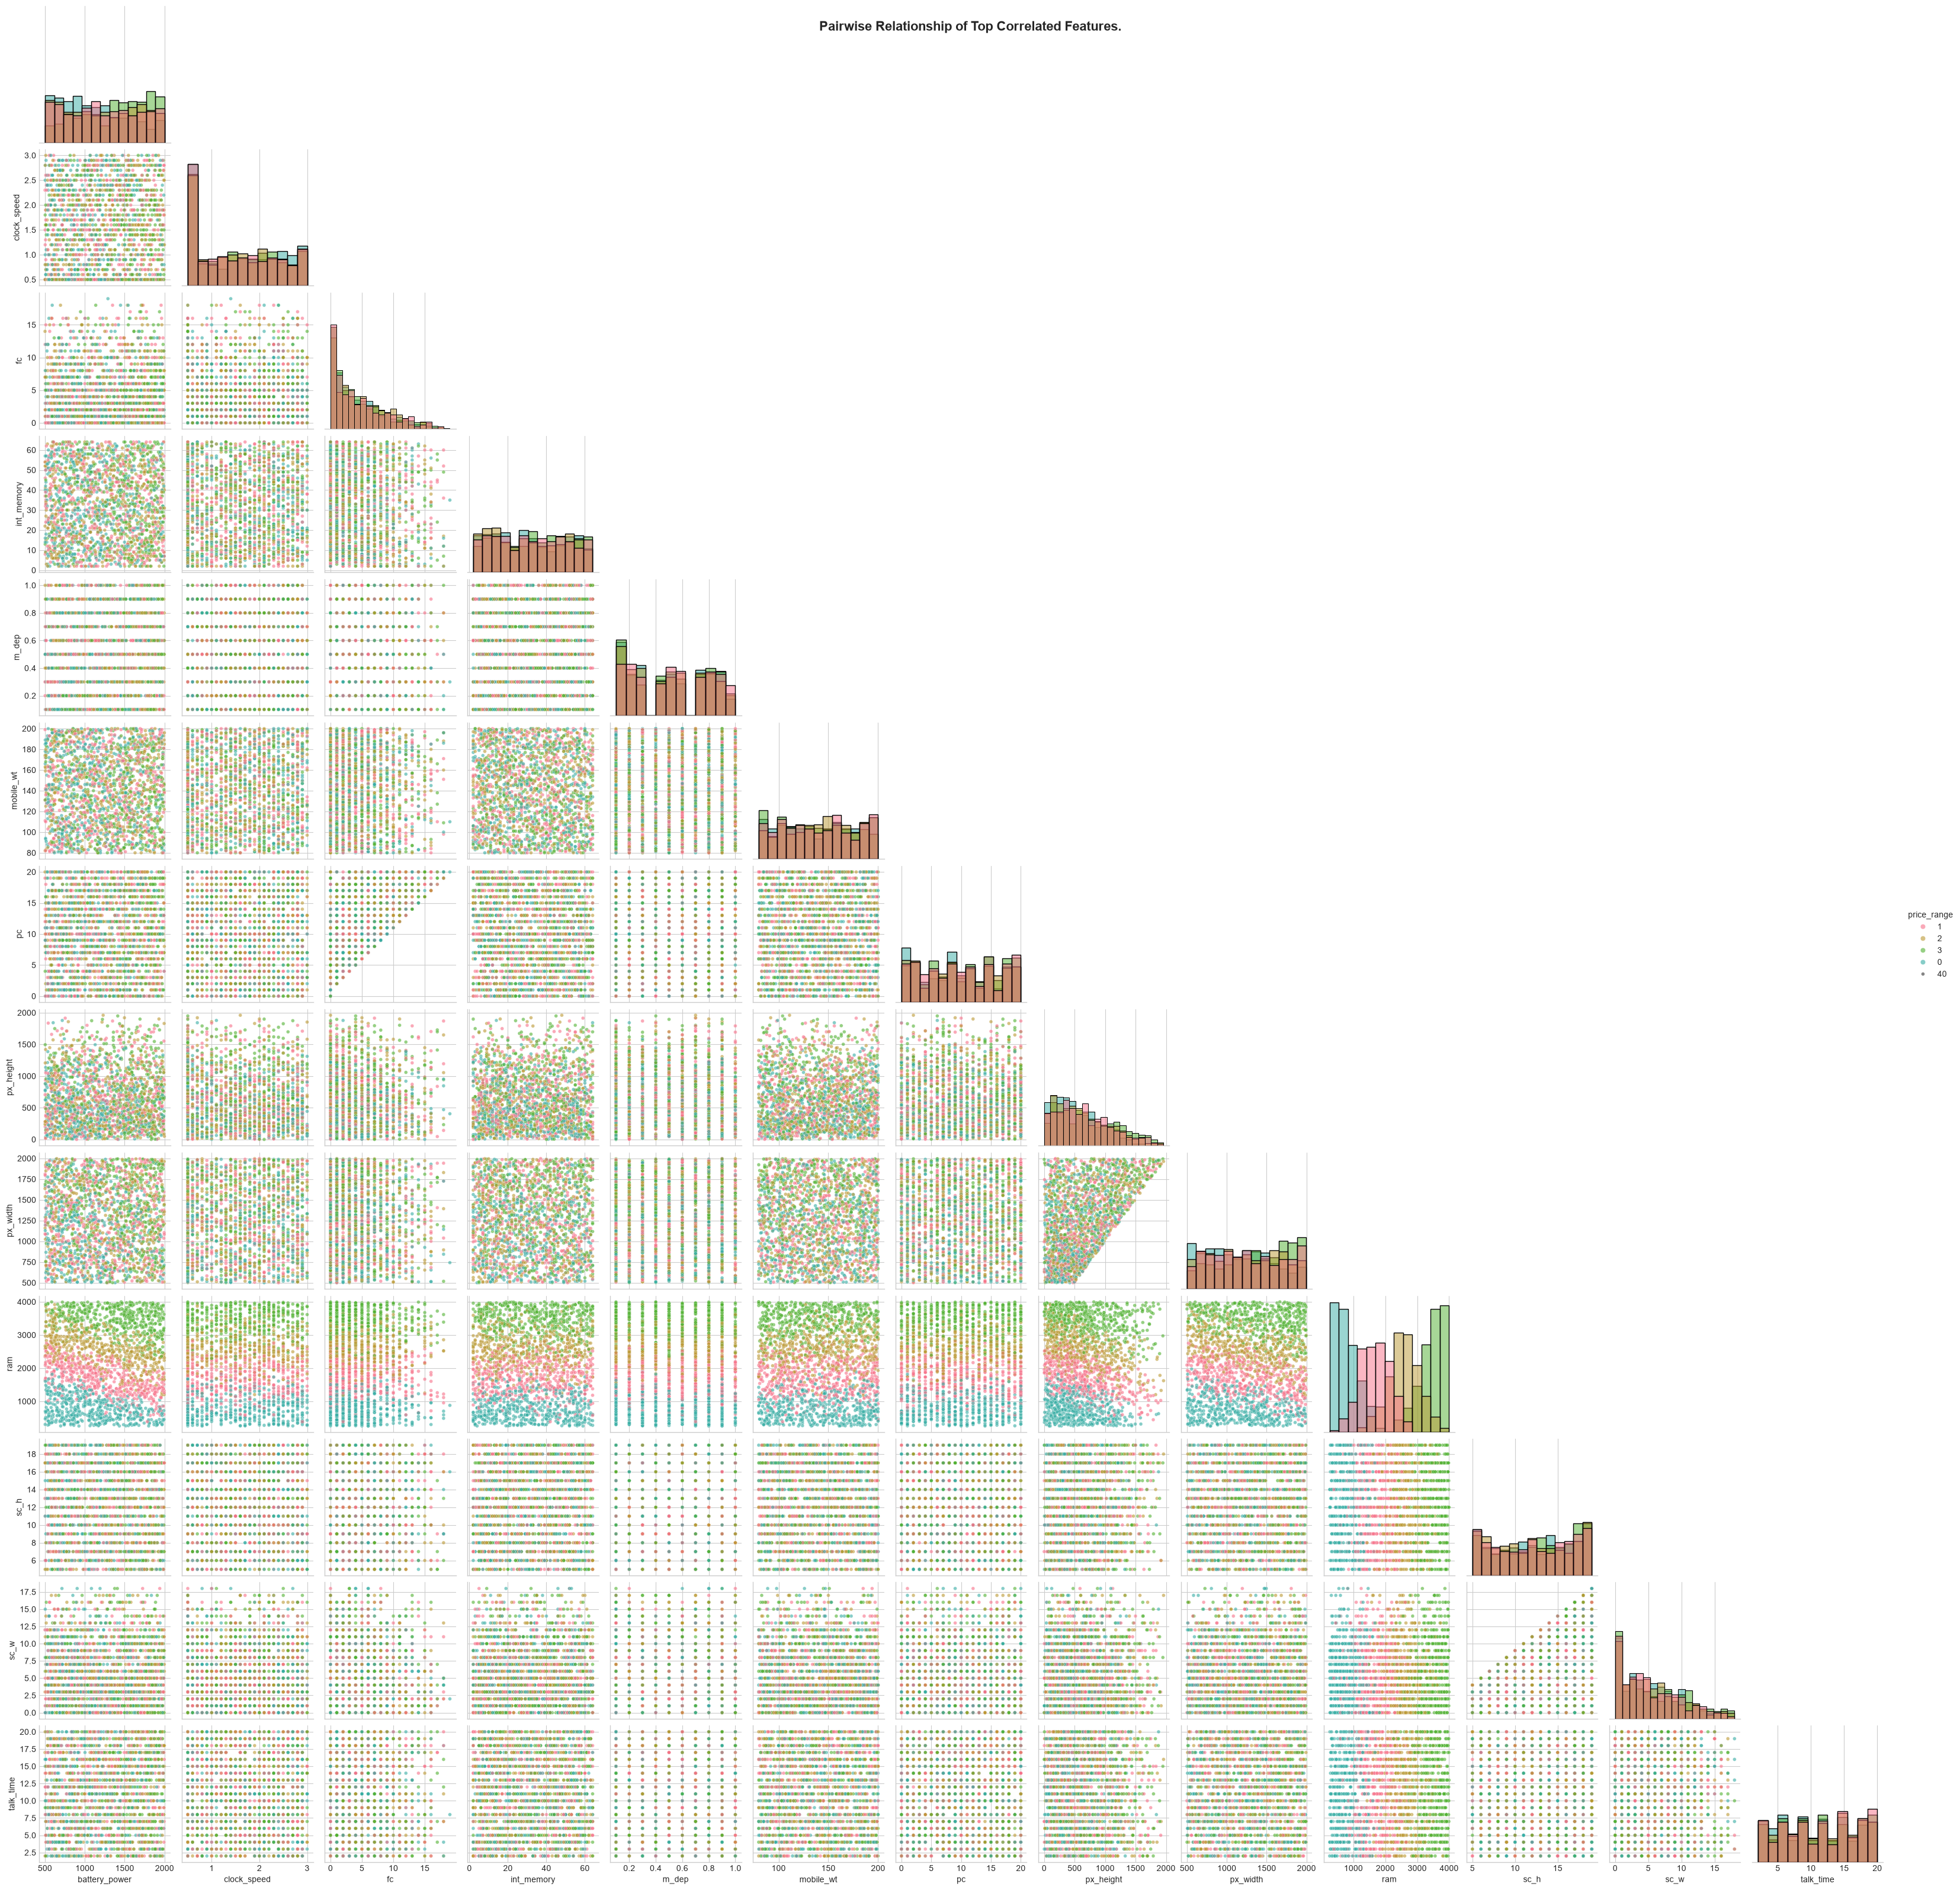

In [17]:
g = sns.pairplot(
  data = df,
  vars=numerical_cols,
  diag_kind='hist',
  hue='price_range',
  corner=True,
  markers='o',
  plot_kws={
    'alpha':0.6,
    'size':40
  }
)

g.fig.suptitle(
  'Pairwise Relationship of Top Correlated Features.',
  fontsize=16,
  fontweight='bold'
)

plt.show()

**Categorical Columns Analysis**

🧩 Categorical Columns Analysis : 

No of Categorical Columns : 7

         Column   p_value p_value_impact  cramers_v_value Cramers_V_Impact
0          blue  0.698018  ❌ No Evidence         0.026760       Negligible
1      dual_sim  0.732350  ❌ No Evidence         0.025362       Negligible
2        four_g  0.364714  ❌ No Evidence         0.039874       Negligible
3       n_cores  0.488294  ❌ No Evidence         0.058487       Negligible
4       three_g  0.711696  ❌ No Evidence         0.026208       Negligible
5  touch_screen  0.274701  ❌ No Evidence         0.044046       Negligible
6          wifi  0.835991  ❌ No Evidence         0.020690       Negligible


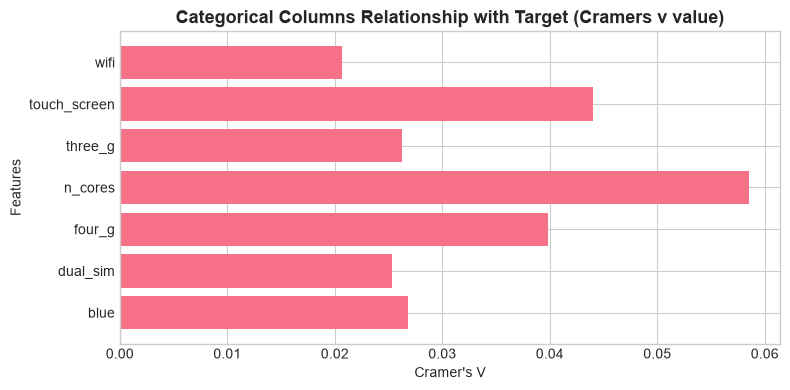

In [18]:
# Univariate Categorical Analysis

print(f'🧩 Categorical Columns Analysis : \n')

print(f'No of Categorical Columns : {len(categorical_columns)-1}\n')


# Calculate Cramer's V finding the relationship b/w Feature vs Target.
def calculate_cramers_value(chi2,table):
  n = table.to_numpy().sum()
  r,c = table.shape
  
  return np.sqrt((chi2)/(n*min(r-1,c-1)))


p_values = []
cramers_v = []

p_val_impact = []
cramers_impact = []

for col in categorical_columns[:-1]:
  table = pd.crosstab(df[col].dropna(),df['price_range'].dropna())
  
  chi2,p_val,dof,expected = stats.chi2_contingency(table)
  
  cramers_value = calculate_cramers_value(chi2,table)
  
  p_values.append(p_val)
  cramers_v.append(cramers_value)
  
  p_impact = ""
  c_impact = ""
  
  # p-value impact
  if p_val <= 0.05:
    p_impact = "✅ Significant Evidence"
  else:
    p_impact = "❌ No Evidence"
  
  p_val_impact.append(p_impact)
    
  # cramer's value impact
  if cramers_value < 0.20:
    c_impact = "Negligible"
  elif cramers_value < 0.50:
    c_impact = "Small"
  elif cramers_value < 0.80:
    c_impact = "Medium"
  elif cramers_value <= 1.00:
    c_impact = "Large"
  else:
    c_impact = "Very Large"
  
  cramers_impact.append(c_impact)
  

# Dataframe
categorical_tar_analysis_df = pd.DataFrame({
  "Column":categorical_columns[:-1],
  "p_value":p_values,
  "p_value_impact":p_val_impact,
  "cramers_v_value":cramers_v,
  "Cramers_V_Impact":cramers_impact
})


print(categorical_tar_analysis_df)
    


plt.figure(figsize=(8,4))
plt.barh(categorical_tar_analysis_df['Column'],categorical_tar_analysis_df['cramers_v_value'])
plt.xlabel("Cramer's V")
plt.ylabel('Features')
plt.title('Categorical Columns Relationship with Target (Cramers v value)',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.show()

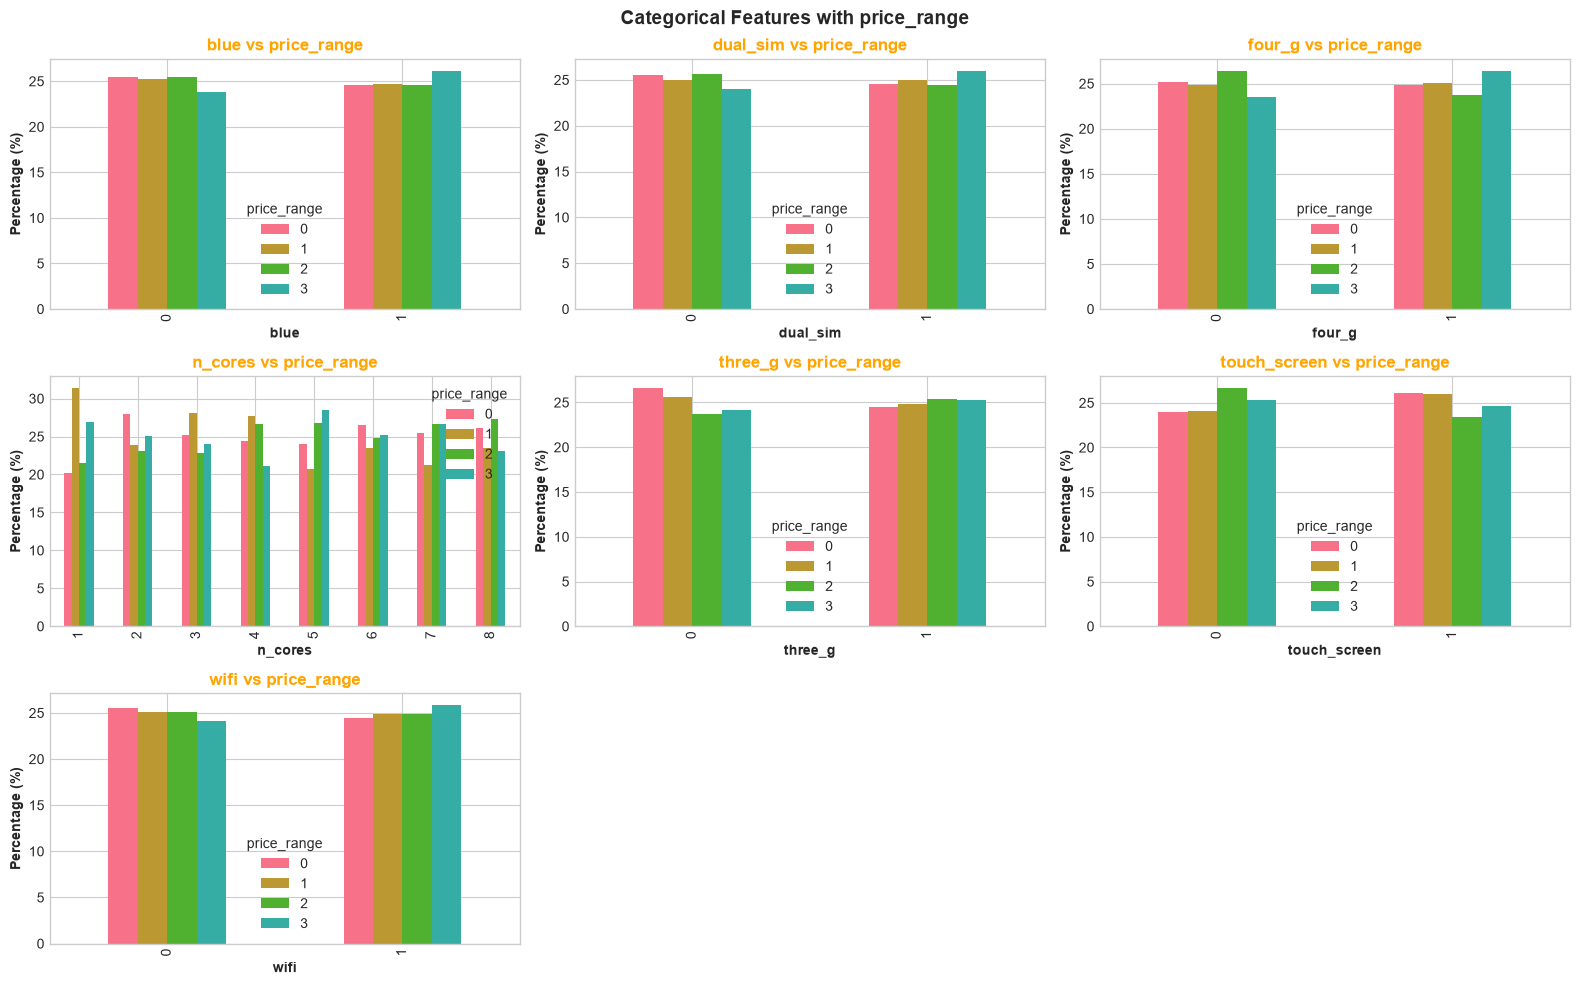

In [19]:
"""
Visualize:
1. Why Categorical columns does not form any relationsip with price_range.
"""

fig,ax = plt.subplots(3,3,figsize=(16,10))

ax = ax.flatten()

for i,col in enumerate(categorical_columns[:-1]):
  table = pd.crosstab(df[col],df['price_range'],normalize='index')*100
  
  table.plot(kind='bar',ax=ax[i])
  ax[i].set_title(f'{col} vs price_range',fontweight='bold',color='orange')
  ax[i].set_ylabel('Percentage (%)',fontweight='bold')
  ax[i].set_xlabel(f'{col}',fontweight='bold')
  

fig.suptitle('Categorical Features with price_range',fontsize=14,fontweight='bold')

plt.tight_layout()

# remove unused plots
for axes in ax[len(categorical_columns[:-1]):]:
  plt.delaxes(axes)

plt.show()



**Outliers Handling**

In [20]:
print(f'⚽ Outliers in column-wise : \n')
for col in numerical_cols:
  
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  
  iqr = q3 - q1

  lower_boundary = q1 - 1.5 * iqr
  upper_boundary = q3 + 1.5 * iqr

  outliers_count = df[(df[col]<lower_boundary) | (df[col]>upper_boundary)].shape[0]
  outliers_percentage = (outliers_count/len(df))*100
  
  print(f'{col:15s} → Count : {outliers_count}  | Percentage : {round(outliers_percentage,3)}')

⚽ Outliers in column-wise : 

battery_power   → Count : 0  | Percentage : 0.0
clock_speed     → Count : 0  | Percentage : 0.0
fc              → Count : 18  | Percentage : 0.9
int_memory      → Count : 0  | Percentage : 0.0
m_dep           → Count : 0  | Percentage : 0.0
mobile_wt       → Count : 0  | Percentage : 0.0
pc              → Count : 0  | Percentage : 0.0
px_height       → Count : 2  | Percentage : 0.1
px_width        → Count : 0  | Percentage : 0.0
ram             → Count : 0  | Percentage : 0.0
sc_h            → Count : 0  | Percentage : 0.0
sc_w            → Count : 0  | Percentage : 0.0
talk_time       → Count : 0  | Percentage : 0.0


<h3 style="color:green;text-align:center">🎯 Exploratory Data Analysis Report </h3>

**Target Variable : Price_range**

1. Small,Medium,Large,Very Large Cost phones. All categories equal numbers. so the price_range is Balanced Taget Variable.


**Distributions**

1. ALL Numerical columns are Approximately Normal Distribution.
2. Front Camera (FC) Follows a High Right skewed Distribution with **skewness : 1.019811**
3. There is no relationship exist between Categorical Features with target variable : **price_range**. using the cramer's V and chi-square Method

In [21]:
# Remove the Outliers. Beacause it has very low percentage

for col in numerical_cols:
  
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  
  iqr = q3 - q1

  lower_boundary = q1 - 1.5 * iqr
  upper_boundary = q3 + 1.5 * iqr

  df = df[(df[col]>lower_boundary) & (df[col]<upper_boundary)]


**🟢 Feature Engineering**

In [22]:
# convert all the categoires columns from object data type to numerical datatype

for col in categorical_columns:
  df[col] = df[col].astype('int')
  

In [23]:
features = df.drop(columns=['price_range'],axis=1)
target = df[['price_range']]

In [24]:
features.shape,target.shape

((1956, 20), (1956, 1))

In [25]:
# Splitting the Data into train and test

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(features,target,test_size=0.25,random_state=42)

In [26]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((1467, 20), (489, 20), (1467, 1), (489, 1))

In [27]:
# standardize the numerical values

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [28]:
x_train_scaled[:5]

array([[ 1.15023437,  1.01996755,  0.07371562, -1.01580311, -0.26179923,
        -1.05827321,  0.91609144,  1.01421515, -1.12625111, -1.54434199,
        -0.12606602,  1.12382998,  0.49638051, -0.15471065, -1.72213682,
        -0.40758594, -0.92073529,  0.55451477, -1.02414974,  1.0171893 ],
       [-0.79856087, -0.98042335, -1.02602141,  0.98444274,  1.25223286,
         0.94493557, -0.24981904, -1.06815522,  0.3169251 ,  0.62655653,
         1.04337568, -0.89826869, -0.88345109, -1.25927177,  1.57446547,
         1.17603116, -0.55685634,  0.55451477, -1.02414974,  1.0171893 ],
       [-0.03490506, -0.98042335,  0.07371562,  0.98444274,  0.24287813,
        -1.05827321, -1.58228816, -0.72109349,  0.82628141,  0.62655653,
        -0.46019222,  1.77427933,  1.03651971, -0.1076098 , -0.78025045,
        -0.86004797, -1.28461424, -1.80337847, -1.02414974, -0.98310118],
       [-1.38546549,  1.01996755, -0.7816354 , -1.01580311, -0.76647659,
         0.94493557, -1.63780771, -1.41521695, -

**Finding feature importance**

         Features        MI
13            ram  0.853583
1            blue  0.044889
12       px_width  0.036194
15           sc_w  0.033453
0   battery_power  0.030192
11      px_height  0.029950
18   touch_screen  0.029188
5          four_g  0.019779
6      int_memory  0.010634
10             pc  0.002650
17        three_g  0.000995
8       mobile_wt  0.000258
3        dual_sim  0.000000
2     clock_speed  0.000000
4              fc  0.000000
7           m_dep  0.000000
9         n_cores  0.000000
14           sc_h  0.000000
16      talk_time  0.000000
19           wifi  0.000000


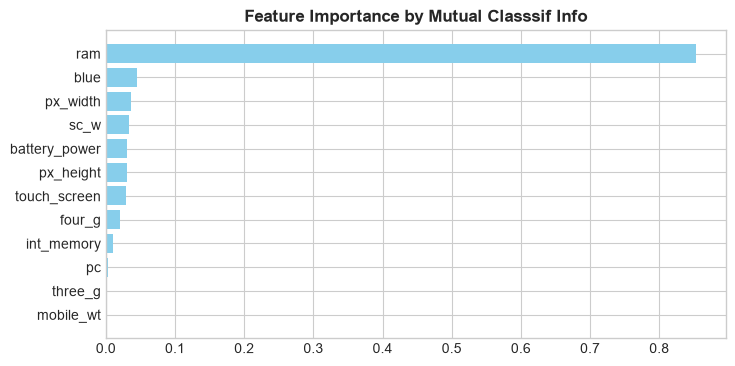

In [29]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(features,target,random_state=42)

mi_df = pd.DataFrame({
  'Features':features.columns,
  "MI":mi
}).sort_values('MI',ascending=False)

print(mi_df)

mi_df = mi_df[mi_df['MI']>0]

# Visualization of important feature by Mutual_info_classif
plt.figure(figsize=(8,4))
plt.barh(mi_df['Features'],mi_df['MI'],color='skyblue')
plt.title('Feature Importance by Mutual Classsif Info',fontweight='bold')
plt.gca().invert_yaxis()
plt.show()


         Features  Importance
13            ram    0.488175
0   battery_power    0.073467
12       px_width    0.056744
11      px_height    0.056197
8       mobile_wt    0.040054
6      int_memory    0.035666
10             pc    0.029810
16      talk_time    0.029583
15           sc_w    0.027828
14           sc_h    0.026287
2     clock_speed    0.026056
7           m_dep    0.024321
4              fc    0.024263
9         n_cores    0.022826
18   touch_screen    0.007148
3        dual_sim    0.007046
5          four_g    0.006664
1            blue    0.006078
19           wifi    0.005977
17        three_g    0.005809


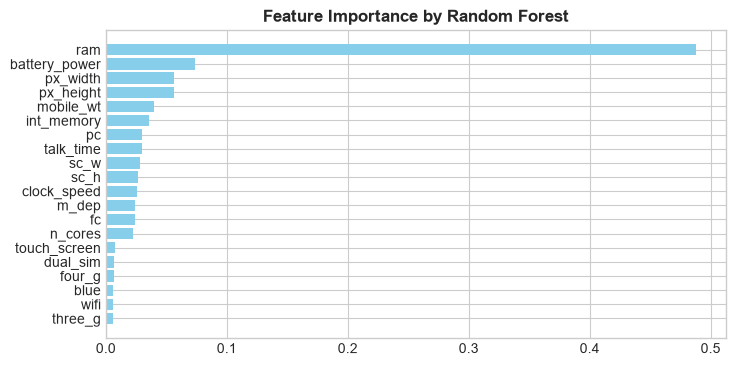

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(features,target)

random_foreset_feature_importance = pd.DataFrame({
  "Features":features.columns,
  "Importance":rf.feature_importances_
}).sort_values('Importance',ascending=False)

print(random_foreset_feature_importance)

# Visualization of important feature by Mutual_info_classif
plt.figure(figsize=(8,4))
plt.barh(random_foreset_feature_importance['Features'],random_foreset_feature_importance['Importance'],color='skyblue')
plt.title('Feature Importance by Random Forest',fontweight='bold')
plt.gca().invert_yaxis()
plt.show()

In [31]:
from sklearn.metrics import accuracy_score,precision_score,f1_score,classification_report,recall_score


# creating function for model evaluation

def model_evaluation(y_true,y_pred):
  acc = accuracy_score(y_true,y_pred)
  precision = precision_score(y_true,y_pred,average='macro',zero_division=0)
  recall = recall_score(y_true,y_pred,average='macro',zero_division=0)
  f1 = f1_score(y_true,y_pred,average='macro',zero_division=0)
  return acc,precision,recall,f1


**🌍 Building the Models**

In [32]:
model_results = []

**Building the Baseline Models**

In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [34]:
models = {
  "Logistic Regression" : LogisticRegression(max_iter=200),
  "KNeighborsClassifier" : KNeighborsClassifier(n_neighbors=5)
}

In [35]:
for model_name,model in list(models.items()):
  
  # training the model
  model.fit(x_train_scaled,y_train)
  
  # Predictions
  y_train_pred = model.predict(x_train_scaled)
  y_test_pred = model.predict(x_test_scaled)
  
  train_acc,train_pre,train_recall,train_f1 = model_evaluation(y_train,y_train_pred)
  test_acc,test_pre,test_recall,test_f1 = model_evaluation(y_test,y_test_pred)
  
  print(f'-------- {model_name} --------')
  print(f'Training Performance : \n')
  print(f'Accuracy : {train_acc}')
  print(f'Precision : {train_pre}')
  print(f'Recall : {train_recall}')
  print(f'F1-Score : {train_f1}')
  print(f'\nTesting Performance : \n')
  print(f'Accuracy : {test_acc}')
  print(f'Precision : {test_pre}')
  print(f'Recall : {test_recall}')
  print(f'F1-Score : {test_f1}')
  
  model_results.append({
    "Model_Name" : model_name,
    "train_accuracy":train_acc,
    "train_precision":train_pre,
    "train_recall":train_recall,
    "train_f1":train_f1,
    "test_accuracy":test_acc,
    "test_precision":test_pre,
    "test_recall":test_recall,
    "test_f1":test_f1
  })

-------- Logistic Regression --------
Training Performance : 

Accuracy : 0.9775051124744376
Precision : 0.9775244603154019
Recall : 0.9774558715444291
F1-Score : 0.9774392715610988

Testing Performance : 

Accuracy : 0.9652351738241309
Precision : 0.965383444769702
Recall : 0.9648026989697126
F1-Score : 0.9650389251658031
-------- KNeighborsClassifier --------
Training Performance : 

Accuracy : 0.6898432174505794
Precision : 0.7029090871803572
Recall : 0.6891329358576772
F1-Score : 0.6907555346708163

Testing Performance : 

Accuracy : 0.5296523517382413
Precision : 0.5509954840092035
Recall : 0.5304841350089076
F1-Score : 0.5320245166826272


In [36]:
# baseline model performance
print(f'📈 Baseline Models Performance : \n')

pd.DataFrame(model_results)

📈 Baseline Models Performance : 



,Model_Name,train_accuracy,train_precision,train_recall,train_f1,test_accuracy,test_precision,test_recall,test_f1
0,Logistic Regression,0.977505,0.977524,0.977456,0.977439,0.965235,0.965383,0.964803,0.965039
1,KNeighborsClassifier,0.689843,0.702909,0.689133,0.690756,0.529652,0.550995,0.530484,0.532025


In [37]:
# Investigating the Logistic regression model

from sklearn.model_selection import cross_val_score

model = LogisticRegression()

cv_scores = cross_val_score(model,x_train_scaled,y_train,cv=5)

print(cv_scores)

print(f'Mean cv scores : {cv_scores.mean()}')
print(f'std cv scores : {cv_scores.std()}')

[0.95238095 0.96598639 0.96587031 0.93515358 0.96587031]
Mean cv scores : 0.9570523089781988
std cv scores : 0.012138433293789387


**Building Intermediate Models to Improve accuracy**

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [39]:
models = {
  "DecisionTreeClassifier":DecisionTreeClassifier(),
  "SVC":SVC(),
  "RandomForestClassifier":RandomForestClassifier()
}

In [40]:
for model_name,model in list(models.items()):
  
  # training the model
  model.fit(x_train_scaled,y_train)
  
  # Predictions
  y_train_pred = model.predict(x_train_scaled)
  y_test_pred = model.predict(x_test_scaled)
  
  train_acc,train_pre,train_recall,train_f1 = model_evaluation(y_train,y_train_pred)
  test_acc,test_pre,test_recall,test_f1 = model_evaluation(y_test,y_test_pred)
  
  print(f'-------- {model_name} --------')
  print(f'Training Performance : \n')
  print(f'Accuracy : {train_acc}')
  print(f'Precision : {train_pre}')
  print(f'Recall : {train_recall}')
  print(f'F1-Score : {train_f1}')
  print(f'\nTesting Performance : \n')
  print(f'Accuracy : {test_acc}')
  print(f'Precision : {test_pre}')
  print(f'Recall : {test_recall}')
  print(f'F1-Score : {test_f1}')
  
  model_results.append({
    "Model_Name" : model_name,
    "train_accuracy":train_acc,
    "train_precision":train_pre,
    "train_recall":train_recall,
    "train_f1":train_f1,
    "test_accuracy":test_acc,
    "test_precision":test_pre,
    "test_recall":test_recall,
    "test_f1":test_f1
  })

-------- DecisionTreeClassifier --------
Training Performance : 

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1-Score : 1.0

Testing Performance : 

Accuracy : 0.820040899795501
Precision : 0.8246165832200241
Recall : 0.8218618859744774
F1-Score : 0.8226865861105036
-------- SVC --------
Training Performance : 

Accuracy : 0.9850034083162917
Precision : 0.9850293580873691
Recall : 0.9849381640541105
F1-Score : 0.9849654841772424

Testing Performance : 

Accuracy : 0.8752556237218814
Precision : 0.8786902846586995
Recall : 0.876726106688041
F1-Score : 0.8766247409279465
-------- RandomForestClassifier --------
Training Performance : 

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1-Score : 1.0

Testing Performance : 

Accuracy : 0.8895705521472392
Precision : 0.8895253837072019
Recall : 0.888746779466758
F1-Score : 0.8887478597858038


**Building Advanced Models**

In [41]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [42]:
models = {
  "XGBoostClassifier":XGBClassifier(),
  "LGBMClassifier":LGBMClassifier(),
  "CatBoostClassifier":CatBoostClassifier()
}

In [43]:
for model_name,model in list(models.items()):
  
  # training the model
  model.fit(x_train_scaled,y_train)
  
  # Predictions
  y_train_pred = model.predict(x_train_scaled)
  y_test_pred = model.predict(x_test_scaled)
  
  train_acc,train_pre,train_recall,train_f1 = model_evaluation(y_train,y_train_pred)
  test_acc,test_pre,test_recall,test_f1 = model_evaluation(y_test,y_test_pred)
  
  print(f'-------- {model_name} --------')
  print(f'Training Performance : \n')
  print(f'Accuracy : {train_acc}')
  print(f'Precision : {train_pre}')
  print(f'Recall : {train_recall}')
  print(f'F1-Score : {train_f1}')
  print(f'\nTesting Performance : \n')
  print(f'Accuracy : {test_acc}')
  print(f'Precision : {test_pre}')
  print(f'Recall : {test_recall}')
  print(f'F1-Score : {test_f1}')
  
  model_results.append({
    "Model_Name" : model_name,
    "train_accuracy":train_acc,
    "train_precision":train_pre,
    "train_recall":train_recall,
    "train_f1":train_f1,
    "test_accuracy":test_acc,
    "test_precision":test_pre,
    "test_recall":test_recall,
    "test_f1":test_f1
  })

-------- XGBoostClassifier --------
Training Performance : 

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1-Score : 1.0

Testing Performance : 

Accuracy : 0.9059304703476483
Precision : 0.905877298097169
Recall : 0.9055417954171894
F1-Score : 0.9054560670015499
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000594 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1366
[LightGBM] [Info] Number of data points in the train set: 1467, number of used features: 20
[LightGBM] [Info] Start training from score -1.372081
[LightGBM] [Info] Start training from score -1.374773
[LightGBM] [Info] Start training from score -1.404871
[LightGBM] [Info] Start training from score -1.393821
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
-------- LGBMClassi

**✅ Model Comparision from basic to advanced**

In [44]:
model_results_df = pd.DataFrame(model_results)

print(model_results_df)

               Model_Name  train_accuracy  train_precision  train_recall  train_f1  test_accuracy  test_precision  test_recall   test_f1
0     Logistic Regression        0.977505         0.977524      0.977456  0.977439       0.965235        0.965383     0.964803  0.965039
1    KNeighborsClassifier        0.689843         0.702909      0.689133  0.690756       0.529652        0.550995     0.530484  0.532025
2  DecisionTreeClassifier        1.000000         1.000000      1.000000  1.000000       0.820041        0.824617     0.821862  0.822687
3                     SVC        0.985003         0.985029      0.984938  0.984965       0.875256        0.878690     0.876726  0.876625
4  RandomForestClassifier        1.000000         1.000000      1.000000  1.000000       0.889571        0.889525     0.888747  0.888748
5       XGBoostClassifier        1.000000         1.000000      1.000000  1.000000       0.905930        0.905877     0.905542  0.905456
6          LGBMClassifier        1.000000

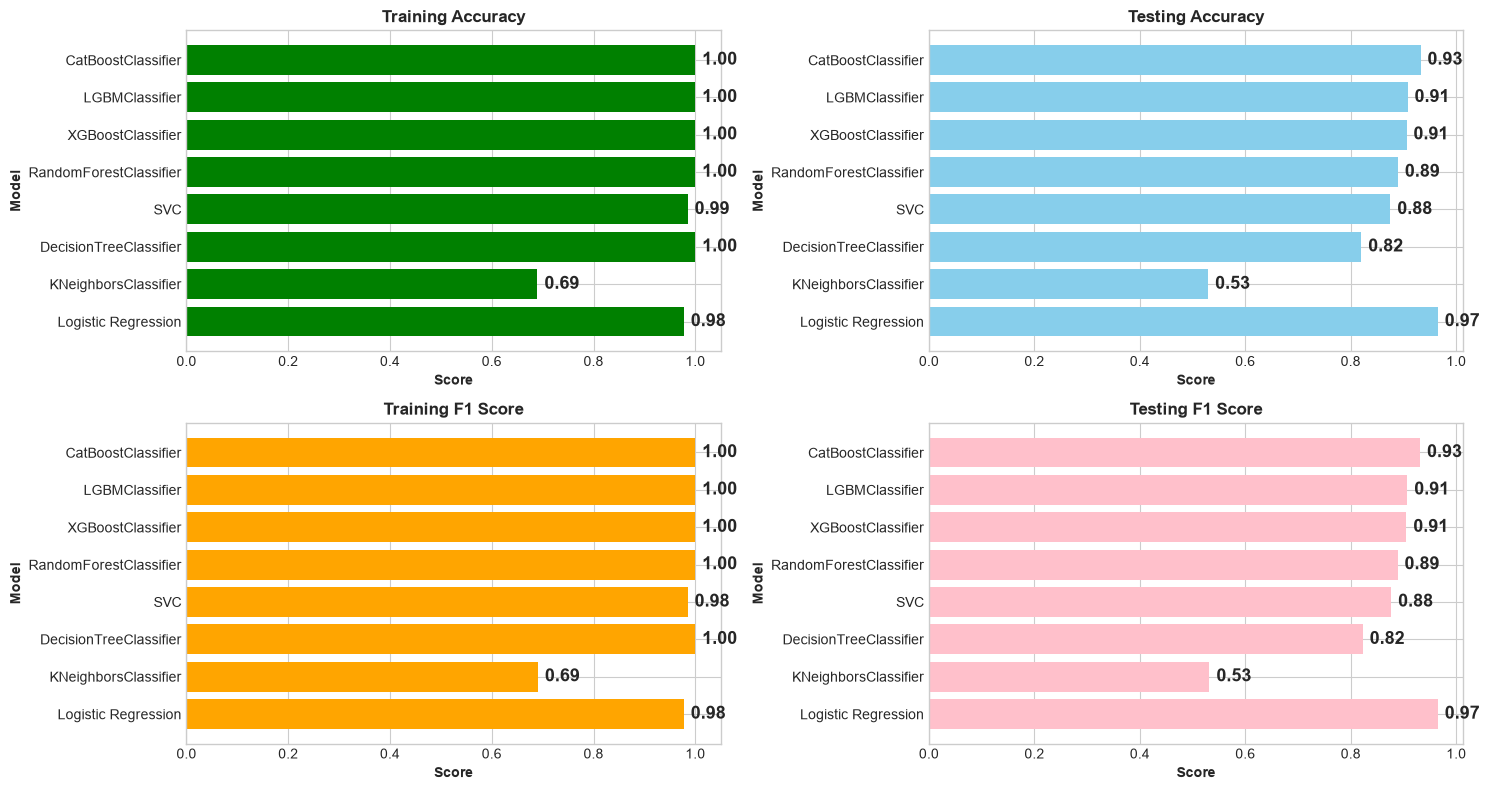

In [45]:
fig, ax = plt.subplots(2, 2, figsize=(15, 8))
ax = ax.flatten()

keys = [
    'train_accuracy',
    'test_accuracy',
    'train_f1',
    'test_f1'
]

titles = {
    'train_accuracy': 'Training Accuracy',
    'test_accuracy': 'Testing Accuracy',
    'train_f1': 'Training F1 Score',
    'test_f1': 'Testing F1 Score'
}

colors = ['green','skyblue','orange','pink']

for i, key in enumerate(keys):

    bars = ax[i].barh(
        model_results_df['Model_Name'],
        model_results_df[key],
        color=colors[i]
    )

    ax[i].bar_label(
        bars,
        labels=[f'{v:.2f}' for v in model_results_df[key]],
        padding=5,
        fontsize=13,
        fontweight='bold'
    )

    ax[i].set_title(
        titles[key],
        fontweight='bold'
    )

    ax[i].set_xlabel('Score', fontweight='bold')
    ax[i].set_ylabel('Model', fontweight='bold')

plt.tight_layout()
plt.show()

**Hyper-parameter Tuning of Logistic Regression**

In [46]:
param_grid = {
  'C':[0.001,0.01,0.1,1,10,100],
  'penalty':['l1','l2'],
  'solver':['lbfgs','saga']
}

In [47]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
  estimator=LogisticRegression(max_iter=200),
  param_grid=param_grid,
  cv=5,
  scoring='f1_macro',
  n_jobs=-1
)

grid_search.fit(x_train_scaled,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...(max_iter=200)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2'], 'solver': ['lbfgs', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the 

In [48]:
# Best parameters of grid search cv

grid_search.best_params_

{'C': 1, 'penalty': 'l1', 'solver': 'saga'}

In [49]:
model = LogisticRegression(max_iter=200,C=1,penalty='l1',solver='saga')

model.fit(x_train_scaled,y_train)


# Predictions
y_train_pred = model.predict(x_train_scaled)
y_test_pred = model.predict(x_test_scaled)

train_acc,train_pre,train_recall,train_f1 = model_evaluation(y_train,y_train_pred)
test_acc,test_pre,test_recall,test_f1 = model_evaluation(y_test,y_test_pred)

print(f'-------- Logistic Regression Hyper Parameter Tuning --------\n')
print(f'Training Performance : \n')
print(f'Accuracy : {train_acc}')
print(f'Precision : {train_pre}')
print(f'Recall : {train_recall}')
print(f'F1-Score : {train_f1}')
print(f'\nTesting Performance : \n')
print(f'Accuracy : {test_acc}')
print(f'Precision : {test_pre}')
print(f'Recall : {test_recall}')
print(f'F1-Score : {test_f1}')


# saving the Model
import pickle

with open('logistic_regression_model.pkl','wb') as file:
  pickle.dump(model,file)
  


-------- Logistic Regression Hyper Parameter Tuning --------

Training Performance : 

Accuracy : 0.9863667348329925
Precision : 0.9863797234121521
Recall : 0.9863211262937374
F1-Score : 0.9863260092707878

Testing Performance : 

Accuracy : 0.9775051124744376
Precision : 0.9777577346345514
Recall : 0.9772935294778511
F1-Score : 0.977463727726359


---
📈 Logistic Regression performs best

In [50]:
print(f'------ Logistic Regression Performance ------\n')
print(model_results_df.loc[0,:])

------ Logistic Regression Performance ------

Model_Name         Logistic Regression
train_accuracy                0.977505
train_precision               0.977524
train_recall                  0.977456
train_f1                      0.977439
test_accuracy                 0.965235
test_precision                0.965383
test_recall                   0.964803
test_f1                       0.965039
Name: 0, dtype: object


**`🧩 Model Performance Report`**

---

Classification Report : 

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       119
           1       0.98      0.96      0.97       115
           2       0.97      0.97      0.97       129
           3       0.98      0.99      0.98       126

    accuracy                           0.98       489
   macro avg       0.98      0.98      0.98       489
weighted avg       0.98      0.98      0.98       489


Confusion Matrix : 



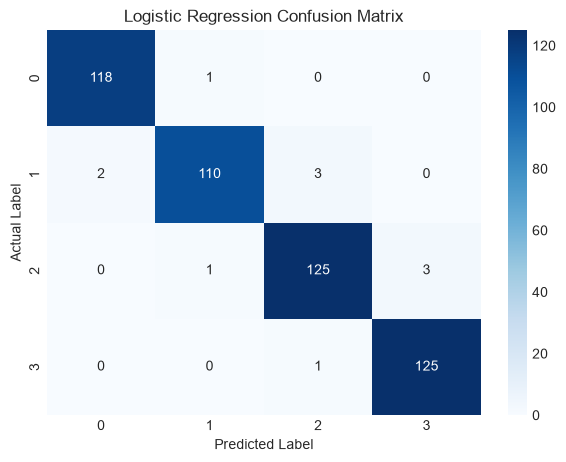

In [51]:
from sklearn.metrics import confusion_matrix,classification_report


print(f'Classification Report : \n')
print(classification_report(
  y_test,y_test_pred,
  zero_division=0
))

print(f'\nConfusion Matrix : \n')
model = LogisticRegression(max_iter=200)

cm = confusion_matrix(y_test,y_test_pred)

# visualization of confusion matrix

plt.figure(figsize=(7,5))

sns.heatmap(
  cm,
  annot=True,
  fmt='d',
  cmap='Blues'
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Logistic Regression Confusion Matrix')
plt.show()


📈 Model Performance 

---

1. Low Cost Phones : Out of **`119`** Low cost Phones. Model Predicted **118** as Low cost Phones

2. Medium cost Phones : Out of **`115`** Medium cost Phones. Model Predicted **110** as Medium cost Phones.

3. High Cost Phones : Out of **`128`** High cost Phones. Model predicted **125** as High cost Phones

4. Very High Cost phones : Out of **`126`** Very High Cost Phones. Model Predicted **125** as Very High Cost Phones.

<h3 style="color:green">🎯 Task 3 : Challenges faced during the EDA and Model creation and Evaluation</h3>

---


**Exploratory Data Analysis**
- Front Camera (FC) and Primary Camera Mega pixels are both are correlated features with **(0.6)**. Identified using the **Chi-square test** and **Cramer's v method**.

- Out of all features **ram** is explained **84%** of variance with target variable **price_range**. 

**Feature Selection**

1. `Mutual Info Classif` : By Mutal Info classif all the most of the categorical variables are not showed relationship with target.

2. `RandomForest` : By random forst ensemble model. we can identify what are best features to build the model and improve the accuracy


**Feature Engineering**

1. **Outliers** : The Outliers are very few percentage less than **1%**. so we remove the Outliers using the Inter-quartile-Range **IQR** Method

2. **Scaling** : Transform all the Numerical values in the range [0 - 1]. Due the Reduce the Impact of large values has larger impact. So we reduce the Variance using the Standard Scaler

**Model Building**

1. Comparing all the Models **Logistic Regression** performs very well with testing f1-score : **98%**


**Hyper-parameter Tuning**

1. Using the Hyper-parameter Tuning for Logistic Regression. We can improve the F1-score **1%**

**Model Evaluation**

1. Using the cross-val-score the Model Explains performs very well in cross-val-scores without decreasing it's f1-score values.

